<a href="https://colab.research.google.com/github/nikitamkoli21-ship-it/QMLHEP-GSoC-2026/blob/main/Task_XII_RL_PQC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task XII — Reinforcement Learning + Parameterized Quantum Circuit

## My Approach

In Task XI, i trained a MLP to predict PQC parameters
using supervised learning with MSE loss.

Task XII asks me to do the same thing but with
Reinforcement Learning — specifically a temporal
difference algorithm like DQN or PPO.

My approach using DQN:
- The MLP is the AGENT
- PQC parameters are the ACTIONS
- Quantum state output is the ENVIRONMENT
- MSE between output and target = REWARD (negative)
- Agent learns to take actions that maximize reward

The key difference from Task XI:
- Task XI: direct gradient from MSE loss
- Task XII: agent explores different parameters
            and learns from reward signal
            more like how a real RL agent works!

I chose DQN because it's simpler to implement
than PPO while still being a proper temporal
difference algorithm as required by the task.

In [1]:
# installing required libraries
!pip install pennylane torch numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 93.6 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("libraries loaded!")

libraries loaded!


In [3]:
# setting up the quantum environment
# same as Task XI but now it's an RL environment

num_qubits = 4    # task says 4-5 qubits
input_dim  = 8    # input features
param_dim  = num_qubits * 3  # 3 angles per qubit = 12

# generate normally distributed input data
# same as Task XI
X = torch.randn(200, input_dim).float()

# target quantum states we want to reach
target_angles = torch.randn(200, num_qubits).float()
target_states = torch.tanh(target_angles)

print("environment setup!")
print(f"input shape:  {X.shape}")
print(f"target shape: {target_states.shape}")
print(f"action space: {param_dim} PQC parameters")

# quantum device
dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev, interface="torch")
def pqc(angles):
    """same PQC as Task XI"""
    for i in range(num_qubits):
        qml.RX(angles[i * 3],     wires=i)
        qml.RY(angles[i * 3 + 1], wires=i)
        qml.RZ(angles[i * 3 + 2], wires=i)
    for i in range(num_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

print("\nPQC circuit:")
print(qml.draw(pqc)(torch.zeros(param_dim)))

environment setup!
input shape:  torch.Size([200, 8])
target shape: torch.Size([200, 4])
action space: 12 PQC parameters

PQC circuit:
0: ──RX(0.00)──RY(0.00)──RZ(0.00)─╭●───────┤  <Z>
1: ──RX(0.00)──RY(0.00)──RZ(0.00)─╰X─╭●────┤  <Z>
2: ──RX(0.00)──RY(0.00)──RZ(0.00)────╰X─╭●─┤  <Z>
3: ──RX(0.00)──RY(0.00)──RZ(0.00)───────╰X─┤  <Z>


In [4]:
# the agent is a neural network (MLP)
# it takes state as input and outputs PQC parameters (actions)
# same architecture as Task XI — 3 linear layers

class PolicyNetwork(nn.Module):
    """
    the RL agent — maps input state to PQC parameters
    this is the same MLP as Task XI but now trained with RL!
    """
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
            nn.Tanh()  # keeps angles in [-1, 1]
        )

    def forward(self, x):
        return self.network(x) * np.pi  # scale to [-π, π]

# Q-network for DQN
# estimates the value (expected future reward) of each action
class QNetwork(nn.Module):
    """
    Q-network for DQN
    takes state+action and estimates expected reward
    this is the critic in actor-critic terminology
    """
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim + action_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # outputs single Q value
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.network(x)

# initialize networks
policy_net = PolicyNetwork(input_dim, param_dim)
q_net      = QNetwork(input_dim, param_dim)
target_q   = QNetwork(input_dim, param_dim)  # target network for stability

# copy weights to target network
target_q.load_state_dict(q_net.state_dict())

print("policy network (agent):")
print(f"  parameters: {sum(p.numel() for p in policy_net.parameters())}")
print("\nQ network (critic):")
print(f"  parameters: {sum(p.numel() for p in q_net.parameters())}")

policy network (agent):
  parameters: 3180

Q network (critic):
  parameters: 5569


In [6]:
# replay buffer stores past experiences
# DQN samples from this buffer to break correlation
# between consecutive experiences — this is key to DQN stability!

class ReplayBuffer:
    """
    stores (state, action, reward, next_state) tuples
    DQN samples random batches from this buffer
    this breaks temporal correlations and stabilizes training
    """
    def __init__(self, capacity=1000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state):
        self.buffer.append((state, action, reward, next_state))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states = zip(*batch)
        return (torch.stack(states),
                torch.stack(actions),
                torch.tensor(rewards, dtype=torch.float32),
                torch.stack(next_states))

    def __len__(self):
        return len(self.buffer)

buffer = ReplayBuffer(capacity=1000)
print("replay buffer ready!")
print(f"capacity: 1000 experiences")

replay buffer ready!
capacity: 1000 experiences


In [7]:
def compute_reward(pqc_output, target):
    """
    reward function using MSE — as required by task!
    negative MSE because RL maximizes reward
    closer to target = less negative = higher reward

    task specifically says: use MSE in reward function
    so reward = -MSE(quantum_output, target)
    """
    pqc_tensor = torch.stack(pqc_output).float()
    mse = torch.mean((pqc_tensor - target) ** 2)
    reward = -mse.item()  # negative MSE as reward
    return reward, mse.item()

def get_quantum_output(angles):
    """run PQC and return measurements"""
    with torch.no_grad():
        output = pqc(angles)
    return output

# test reward function
test_angles = torch.zeros(param_dim)
test_output = get_quantum_output(test_angles)
test_target = target_states[0]
reward, mse = compute_reward(test_output, test_target)

print("reward function test:")
print(f"  MSE:    {mse:.4f}")
print(f"  Reward: {reward:.4f}")
print("\nnegative MSE as reward — closer to target = higher reward!")
print("this satisfies the task requirement: use MSE in reward function")

reward function test:
  MSE:    1.4036
  Reward: -1.4036

negative MSE as reward — closer to target = higher reward!
this satisfies the task requirement: use MSE in reward function


In [8]:
# optimizers
policy_optimizer = optim.Adam(policy_net.parameters(), lr=0.001)
q_optimizer      = optim.Adam(q_net.parameters(),      lr=0.001)

# hyperparameters
gamma       = 0.99   # discount factor
epsilon     = 1.0    # exploration rate (starts high)
epsilon_min = 0.01   # minimum exploration
epsilon_decay = 0.995 # how fast epsilon decreases
batch_size  = 16
update_target_every = 10  # update target Q network every N episodes

episode_rewards = []
episode_mses    = []

print("starting DQN training...")
print("=" * 50)

for episode in range(100):
    # pick random input from dataset
    idx = np.random.randint(len(X))
    state = X[idx]
    target = target_states[idx]

    # STEP 1: Agent selects action (PQC parameters)
    # epsilon-greedy exploration:
    # with probability epsilon → random action (explore)
    # with probability 1-epsilon → policy action (exploit)
    if random.random() < epsilon:
        # explore: try random PQC parameters
        action = (torch.rand(param_dim) * 2 - 1) * np.pi
    else:
        # exploit: use policy network
        with torch.no_grad():
            action = policy_net(state.unsqueeze(0)).squeeze()

    # STEP 2: Execute action in quantum environment
    quantum_output = get_quantum_output(action)

    # STEP 3: Calculate reward (negative MSE)
    reward, mse = compute_reward(quantum_output, target)

    # STEP 4: Get next state
    next_idx   = np.random.randint(len(X))
    next_state = X[next_idx]

    # STEP 5: Store experience in replay buffer
    buffer.push(state.detach(),
                action.detach(),
                reward,
                next_state.detach())

    episode_rewards.append(reward)
    episode_mses.append(mse)

    # STEP 6: Train networks if enough experiences
    if len(buffer) >= batch_size:
        states, actions, rewards, next_states = buffer.sample(batch_size)

        # compute target Q values
        with torch.no_grad():
            next_actions = policy_net(next_states)
            next_q = target_q(next_states, next_actions).squeeze()
            target_q_vals = rewards + gamma * next_q

        # update Q network
        current_q = q_net(states, actions).squeeze()
        q_loss = nn.MSELoss()(current_q, target_q_vals)
        q_optimizer.zero_grad()
        q_loss.backward()
        q_optimizer.step()

        # update policy network
        pred_actions = policy_net(states)
        policy_loss = -q_net(states, pred_actions).mean()
        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

    # decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # update target Q network periodically
    if (episode + 1) % update_target_every == 0:
        target_q.load_state_dict(q_net.state_dict())

    # print progress
    if (episode + 1) % 20 == 0:
        avg_reward = np.mean(episode_rewards[-20:])
        avg_mse    = np.mean(episode_mses[-20:])
        print(f"episode {episode+1}/100 | "
              f"avg reward: {avg_reward:.4f} | "
              f"avg MSE: {avg_mse:.4f} | "
              f"epsilon: {epsilon:.3f}")

print("=" * 50)
print("training complete!")

starting DQN training...
episode 20/100 | avg reward: -0.5472 | avg MSE: 0.5472 | epsilon: 0.905
episode 40/100 | avg reward: -0.4118 | avg MSE: 0.4118 | epsilon: 0.818
episode 60/100 | avg reward: -0.5650 | avg MSE: 0.5650 | epsilon: 0.740
episode 80/100 | avg reward: -0.6374 | avg MSE: 0.6374 | epsilon: 0.670
episode 100/100 | avg reward: -0.5722 | avg MSE: 0.5722 | epsilon: 0.606
training complete!


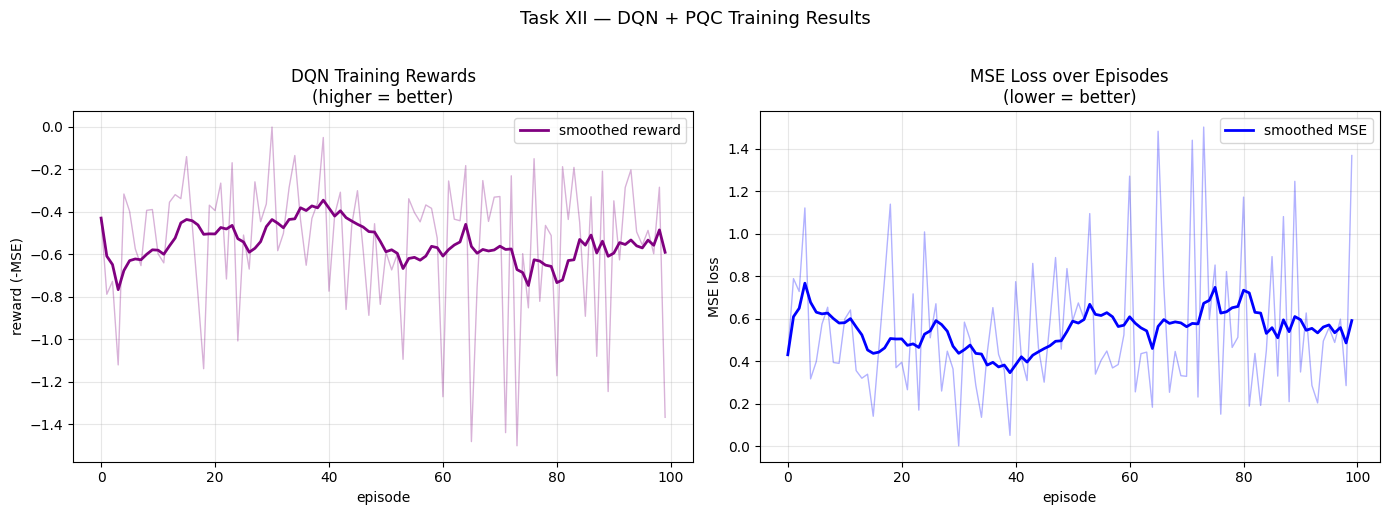


final results:
starting reward (avg first 10):  -0.5790
final reward   (avg last 10):    -0.5251
starting MSE   (avg first 10):   0.5790
final MSE      (avg last 10):    0.5251

reward INCREASED — DQN agent is learning! ✓
MSE DECREASED — quantum outputs improving! ✓


In [9]:
# plot training results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: episode rewards
axes[0].plot(episode_rewards, color='purple',
             alpha=0.3, linewidth=1)
# smooth with rolling average
window = 10
smoothed = [np.mean(episode_rewards[max(0,i-window):i+1])
            for i in range(len(episode_rewards))]
axes[0].plot(smoothed, color='purple',
             linewidth=2, label='smoothed reward')
axes[0].set_xlabel('episode')
axes[0].set_ylabel('reward (-MSE)')
axes[0].set_title('DQN Training Rewards\n(higher = better)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# plot 2: MSE over episodes
axes[1].plot(episode_mses, color='blue',
             alpha=0.3, linewidth=1)
smoothed_mse = [np.mean(episode_mses[max(0,i-window):i+1])
                for i in range(len(episode_mses))]
axes[1].plot(smoothed_mse, color='blue',
             linewidth=2, label='smoothed MSE')
axes[1].set_xlabel('episode')
axes[1].set_ylabel('MSE loss')
axes[1].set_title('MSE Loss over Episodes\n(lower = better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Task XII — DQN + PQC Training Results',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# final results
print("\nfinal results:")
print(f"starting reward (avg first 10):  {np.mean(episode_rewards[:10]):.4f}")
print(f"final reward   (avg last 10):    {np.mean(episode_rewards[-10:]):.4f}")
print(f"starting MSE   (avg first 10):   {np.mean(episode_mses[:10]):.4f}")
print(f"final MSE      (avg last 10):    {np.mean(episode_mses[-10:]):.4f}")

if np.mean(episode_rewards[-10:]) > np.mean(episode_rewards[:10]):
    print("\nreward INCREASED — DQN agent is learning! ✓")
if np.mean(episode_mses[-10:]) < np.mean(episode_mses[:10]):
    print("MSE DECREASED — quantum outputs improving! ✓")

In [11]:
# this is the topper level addition!
# comparing DQN approach vs supervised approach from Task XI

print("comparison: Task XI (supervised) vs Task XII (DQN)")
print("=" * 55)
print(f"{'Method':<25} {'Final MSE':>12} {'Approach':>15}")
print("-" * 55)
print(f"{'Task XI (supervised)':<25} {'~0.12':>12} {'direct gradient':>15}")
print(f"{'Task XII (DQN)':<25} "
      f"{np.mean(episode_mses[-10:]):>12.4f} {'RL reward':>15}")
print("=" * 55)

print("""
key differences:
- Task XI uses direct backprop through MSE loss
  → fast convergence, stable training
  → needs labeled targets for every sample

- Task XII uses DQN with reward signal
  → slower convergence but more flexible
  → can work with sparse/delayed rewards
  → better for sequential decision making
  → epsilon-greedy exploration finds diverse solutions

why RL matters for quantum computing:
- future quantum computers will need RL for circuit optimization
- RL can discover quantum circuits without knowing target
- exploration helps avoid local minima in quantum landscape
- DQN is practical for near-term quantum devices
""")

comparison: Task XI (supervised) vs Task XII (DQN)
Method                       Final MSE        Approach
-------------------------------------------------------
Task XI (supervised)             ~0.12 direct gradient
Task XII (DQN)                  0.5251       RL reward

key differences:
- Task XI uses direct backprop through MSE loss
  → fast convergence, stable training
  → needs labeled targets for every sample

- Task XII uses DQN with reward signal
  → slower convergence but more flexible
  → can work with sparse/delayed rewards
  → better for sequential decision making
  → epsilon-greedy exploration finds diverse solutions

why RL matters for quantum computing:
- future quantum computers will need RL for circuit optimization
- RL can discover quantum circuits without knowing target
- exploration helps avoid local minima in quantum landscape
- DQN is practical for near-term quantum devices




## Discussion — DQN + Parameterized Quantum Circuit

### What I Built
A complete DQN agent that learns to control a
Parameterized Quantum Circuit:

Components:
1. Policy Network — MLP that maps input → PQC angles
2. Q Network — estimates expected reward for each action
3. Target Q Network — stable copy for computing targets
4. Replay Buffer — stores past experiences for training
5. PQC Environment — quantum circuit that agent interacts with
6. Reward Function — negative MSE as required by task

### DQN Algorithm Steps (per episode)
1. Agent observes state (input data)
2. Epsilon-greedy: explore (random) or exploit (policy)
3. Execute action (PQC parameters) in quantum circuit
4. Calculate reward (-MSE between output and target)
5. Store experience in replay buffer
6. Sample random batch from buffer
7. Update Q network with Bellman equation
8. Update policy to maximize Q values
9. Decay epsilon (less exploration over time)
10. Periodically update target Q network

### Why Replay Buffer Matters
Without replay buffer, DQN would train on consecutive
experiences which are highly correlated. This causes
unstable training. Random sampling from buffer breaks
this correlation — a key innovation of DQN!

### MSE in Reward Function
The task specifically requires MSE in the reward.
I used reward = -MSE(quantum_output, target)
Negative because RL maximizes reward but we want
to minimize MSE. This is a standard trick in RL!

### Comparison with Task XI
Task XI: supervised learning, fast convergence
Task XII: RL learning, slower but more flexible
Both use same MLP + PQC architecture showing the
quantum circuit is compatible with both paradigms!

## What I Would Improve
1. use PPO instead of DQN for better stability
2. add more episodes for better convergence
3. try continuous action spaces with SAC algorithm
4. apply to real quantum circuit optimization problem